File permissions: 0o100644
Epoch 1: Train Loss: 0.882262, Valid Loss: 0.525589
Epoch 2: Train Loss: 0.436207, Valid Loss: 0.427637
Epoch 3: Train Loss: 0.357267, Valid Loss: 0.333064
Epoch 4: Train Loss: 0.294472, Valid Loss: 0.290977
Epoch 5: Train Loss: 0.259040, Valid Loss: 0.266484
Epoch 6: Train Loss: 0.232683, Valid Loss: 0.243485
Epoch 7: Train Loss: 0.208890, Valid Loss: 0.218907
Epoch 8: Train Loss: 0.187807, Valid Loss: 0.210348
Epoch 9: Train Loss: 0.175072, Valid Loss: 0.202985
Epoch 10: Train Loss: 0.163462, Valid Loss: 0.196038
Epoch 11: Train Loss: 0.152216, Valid Loss: 0.172364
Epoch 12: Train Loss: 0.145711, Valid Loss: 0.171653
Epoch 13: Train Loss: 0.132065, Valid Loss: 0.157283
Epoch 14: Train Loss: 0.127323, Valid Loss: 0.153563
Epoch 15: Train Loss: 0.115107, Valid Loss: 0.149956
Epoch 16: Train Loss: 0.112676, Valid Loss: 0.152040
Epoch 17: Train Loss: 0.104509, Valid Loss: 0.140288
Epoch 18: Train Loss: 0.101922, Valid Loss: 0.131107
Epoch 19: Train Loss: 0.0936

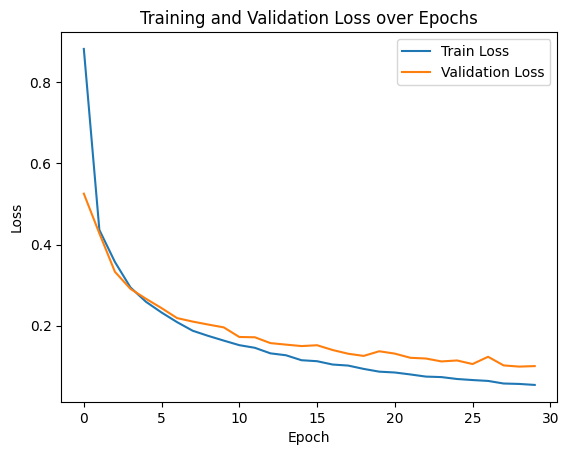

Testing completed in 4.225805 seconds


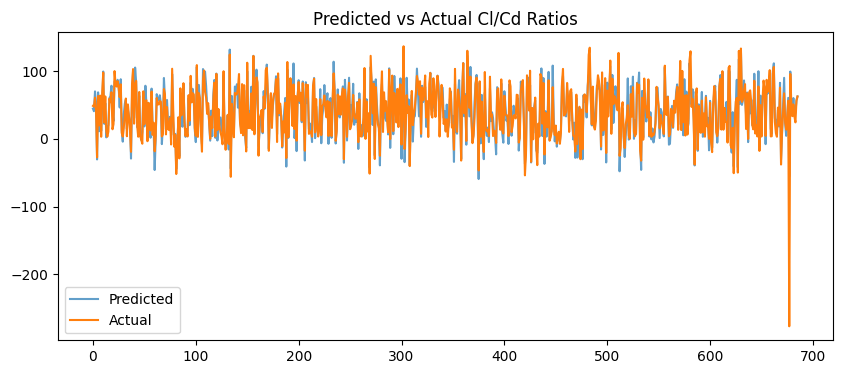

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import scipy.io
import time
import os

# Check if the file exists
if not os.path.exists('/content/sample_data/1_300.mat'):
    print('File does not exist.')

# Check if the file is empty
if os.path.getsize('/content/sample_data/1_300.mat') == 0:
    print('File is empty.')

# Check the file permissions
permissions = oct(os.stat('/content/sample_data/1_300.mat').st_mode)
print('File permissions:', permissions)

# Load data
data = scipy.io.loadmat('/content/sample_data/1_300.mat')
data_x, data_y, rNorm = data['data_x'], data['data_y'], data['Normalization_Factor']
num_data = data_x.shape[0]

# Split data into training, validation, and testing sets
train_ratio, valid_ratio = 0.7, 0.2
train_x, train_y = data_x[:int(train_ratio * num_data)], data_y[:int(train_ratio * num_data)]
valid_x, valid_y = data_x[int(valid_ratio * num_data):int((valid_ratio + 0.7) * num_data)], data_y[int(valid_ratio * num_data):int((valid_ratio + 0.7) * num_data)]
test_x, test_y = data_x[int(0.9 * num_data):], data_y[int(0.9 * num_data):]

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 10, 13), nn.BatchNorm2d(10), nn.MaxPool2d(2, 2), nn.ReLU(),
            nn.Conv2d(10, 20, 7), nn.BatchNorm2d(20), nn.MaxPool2d(2, 2), nn.ReLU(),
            nn.Conv2d(20, 40, 7), nn.BatchNorm2d(40), nn.MaxPool2d(2, 2), nn.ReLU(),
            nn.Conv2d(40, 80, 5), nn.BatchNorm2d(80), nn.MaxPool2d(2, 2), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(720, 400), nn.ReLU(),
            nn.Linear(400, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

# Setup training environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
criterion = nn.MSELoss()

# Prepare data loaders
def create_data_loader(x, y, batch_size, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(x).float(), torch.from_numpy(y).float())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = create_data_loader(train_x, train_y, 50, shuffle=True)
valid_loader = create_data_loader(valid_x, valid_y, 50)
test_loader = create_data_loader(test_x, test_y, 50)

# Training loop
num_epochs = 30
train_losses, valid_losses = [], []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.view(-1, 1, 128, 128).to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)

    model.eval()
    with torch.no_grad():
        total_val_loss = 0
        for inputs, targets in valid_loader:
            inputs, targets = inputs.view(-1, 1, 128, 128).to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
        valid_losses.append(total_val_loss)
    print(f'Epoch {epoch + 1}: Train Loss: {total_loss:.6f}, Valid Loss: {total_val_loss:.6f}')

# Visualization of training and validation loss
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss over Epochs')
plt.show()

# Testing and Visualization
start_time = time.time()
predicted, actual = [], []
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.view(-1, 1, 128, 128).to(device)
        outputs = model(inputs)
        predicted.extend(outputs.cpu().numpy())
        actual.extend(targets.numpy())
end_time = time.time()

print(f'Testing completed in {end_time - start_time:.6f} seconds')

# Rescale predictions and actual values by normalization factor
predicted = [p * rNorm[0,0] for p in predicted]
actual = [a * rNorm[0,0] for a in actual]

# Plotting Predicted vs Actual values
plt.figure(figsize=(10, 4))
plt.plot(predicted, label='Predicted', alpha=0.7)
plt.plot(actual, label='Actual')
plt.legend()
plt.title('Predicted vs Actual Cl/Cd Ratios')
plt.show()


In [ ]:

# MSE Logic
# Testing and Visualization
start_time = time.time()
predicted, actual = [], []
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.view(-1, 1, 128, 128).to(device)
        outputs = model(inputs)
        predicted.extend(outputs.cpu().numpy())
        actual.extend(targets.numpy())
end_time = time.time()

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(np.array(predicted).flatten() - np.array(actual).flatten()))
print(f'Mean Absolute Error (MAE): {mae:.4f}')


# Optionally, calculate efficiency
# Define efficiency as 1 - MAE if you want a simple inverse relation
efficiency = 1 - mae
print(f'Efficiency: {efficiency:.4f}%')

# Rescale predictions and actual values by normalization factor
predicted = [p * rNorm[0,0] for p in predicted]
actual = [a * rNorm[0,0] for a in actual]

# Define function to categorize predictions
def categorize_ratios(ratios, threshold=1.0):  # Set threshold as needed
    return np.where(np.array(ratios) > threshold, 1, 0)

# Categorize the actual and predicted values
categorized_actual = categorize_ratios(actual)
categorized_predicted = categorize_ratios(predicted)

from sklearn.metrics import confusion_matrix, accuracy_score

# Calculate confusion matrix and accuracy
conf_matrix = confusion_matrix(categorized_actual, categorized_predicted)

accuracy = accuracy_score(categorized_actual, categorized_predicted)

print('Confusion Matrix:\n', conf_matrix)
print(f'Accuracy: {accuracy:.4f}')